# Summary plots

This notebook collects the main results of the project.

No receiver optimization is performed here. Numerical optimization results
from the previous notebooks are loaded from saved data files and used to
produce presentation-ready figures.

In [2]:
import numpy as np
import matplotlib.pyplot as plt

from dolinar_receiver.receivers import (
    helstrom_error,
    homodyne_error,
    kennedy_error,
    optimized_displacement,
)

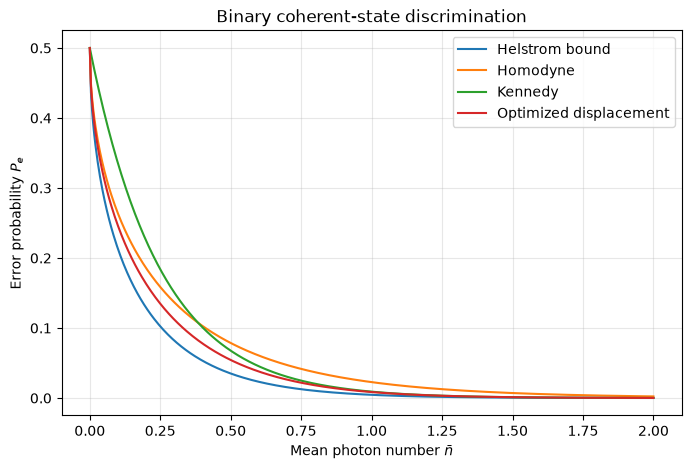

In [3]:
nbar = np.linspace(0, 2, 500)

optimized_errors = np.array([
    optimized_displacement(n)[1]
    for n in nbar
])

fig, ax = plt.subplots(figsize=(8, 5))

ax.plot(nbar, helstrom_error(nbar), label="Helstrom bound")
ax.plot(nbar, homodyne_error(nbar), label="Homodyne")
ax.plot(nbar, kennedy_error(nbar), label="Kennedy")
ax.plot(nbar, optimized_errors, label="Optimized displacement")

ax.set_xlabel(r"Mean photon number $\bar{n}$")
ax.set_ylabel(r"Error probability $P_e$")
ax.set_title("Binary coherent-state discrimination")

ax.grid(alpha=0.3)
ax.legend()

fig.savefig(
    "../figures/summary_receiver_benchmarks.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

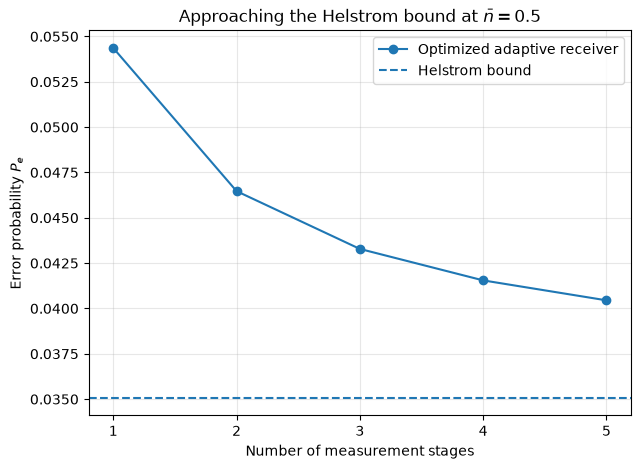

In [4]:
data = np.load("../data/stage_convergence_n05.npz")

stages = data["stages"]
errors = data["errors"]

nbar_test = 0.5
helstrom = helstrom_error(nbar_test)

fig, ax = plt.subplots(figsize=(7, 5))

ax.plot(
    stages,
    errors,
    marker="o",
    label="Optimized adaptive receiver"
)

ax.axhline(
    helstrom,
    linestyle="--",
    label="Helstrom bound"
)

ax.set_xticks(stages)

ax.set_xlabel("Number of measurement stages")
ax.set_ylabel(r"Error probability $P_e$")
ax.set_title(r"Approaching the Helstrom bound at $\bar{n}=0.5$")

ax.grid(alpha=0.3)
ax.legend()

fig.savefig(
    "../figures/summary_stages_vs_helstrom.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

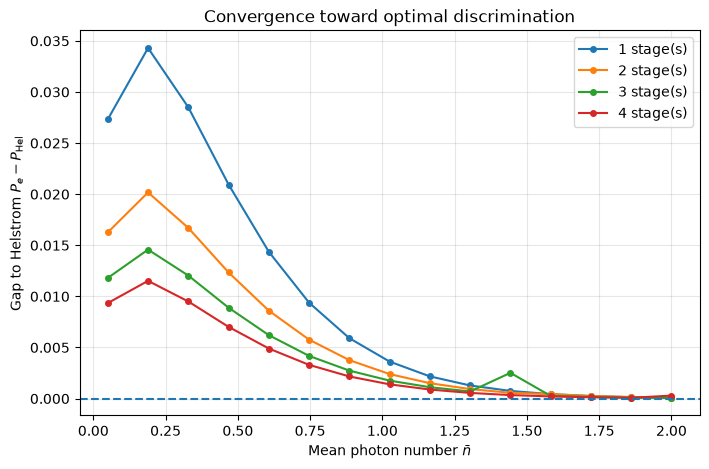

In [5]:
data = np.load("../data/adaptive_stage_sweep.npz")

nbar_values = data["nbar_values"]
helstrom_values = helstrom_error(nbar_values)

fig, ax = plt.subplots(figsize=(8, 5))

for stages in [1, 2, 3, 4]:

    errors = data[f"errors_{stages}"]

    ax.plot(
        nbar_values,
        errors - helstrom_values,
        marker="o",
        markersize=4,
        label=f"{stages} stage(s)"
    )

ax.axhline(0, linestyle="--")

ax.set_xlabel(r"Mean photon number $\bar{n}$")
ax.set_ylabel(r"Gap to Helstrom $P_e-P_{\mathrm{Hel}}$")
ax.set_title("Convergence toward optimal discrimination")

ax.grid(alpha=0.3)
ax.legend()

fig.savefig(
    "../figures/summary_gap_to_helstrom.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

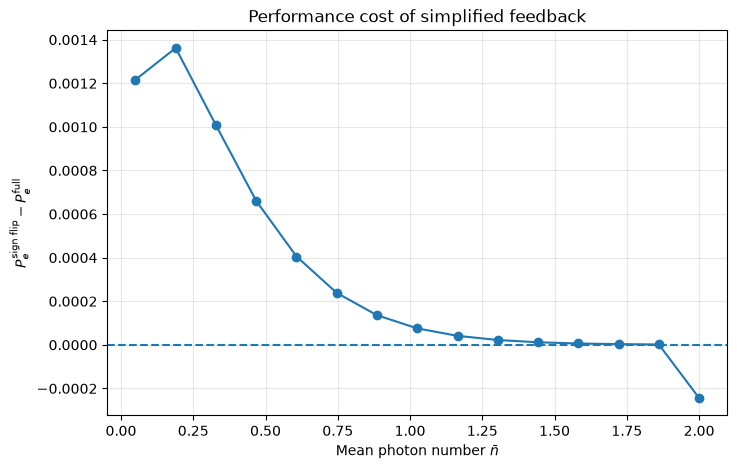

In [6]:
data = np.load("../data/feedback_strategy_sweep.npz")

nbar_values = data["nbar_values"]
full_errors = data["full_tree_errors"]
sign_errors = data["sign_flip_errors"]

penalty = sign_errors - full_errors

fig, ax = plt.subplots(figsize=(8, 5))

ax.plot(
    nbar_values,
    penalty,
    marker="o"
)

ax.axhline(0, linestyle="--")

ax.set_xlabel(r"Mean photon number $\bar{n}$")
ax.set_ylabel(
    r"$P_e^{\mathrm{sign\ flip}}-P_e^{\mathrm{full}}$"
)
ax.set_title("Performance cost of simplified feedback")

ax.grid(alpha=0.3)

fig.savefig(
    "../figures/summary_feedback_complexity.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

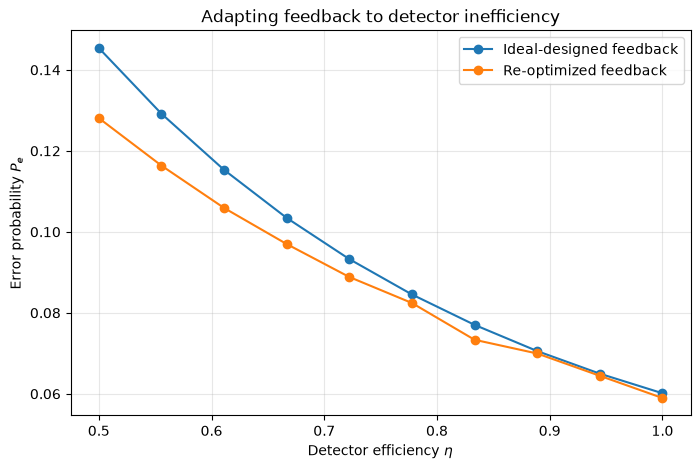

In [7]:
data = np.load("../data/efficiency_sweep.npz")

eta = data["eta_values"]
ideal_feedback = data["ideal_strategy_errors"]
reoptimized = data["reoptimized_errors"]

fig, ax = plt.subplots(figsize=(8, 5))

ax.plot(
    eta,
    ideal_feedback,
    marker="o",
    label="Ideal-designed feedback"
)

ax.plot(
    eta,
    reoptimized,
    marker="o",
    label="Re-optimized feedback"
)

ax.set_xlabel(r"Detector efficiency $\eta$")
ax.set_ylabel(r"Error probability $P_e$")
ax.set_title("Adapting feedback to detector inefficiency")

ax.grid(alpha=0.3)
ax.legend()

fig.savefig(
    "../figures/summary_detector_efficiency.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()